<a href="https://colab.research.google.com/github/vidyadharne08-byte/CSL701-CS-12_Machine-Learning-Lab/blob/main/CS12_ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Vidya Rajan Dharne
Roll no : CS12
Batch : CS1

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

# --------------------------------------------------
# Upload ZIP dataset
# --------------------------------------------------
from google.colab import files

uploaded = files.upload()

# --------------------------------------------------
# Extract ZIP file
# --------------------------------------------------
zip_file = 'diabetes dataset.zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('diabetes_data')

# Show files extracted from the ZIP
print("Extracted files:")
for root, dirs, files_list in os.walk('diabetes_data'):
    for file in files_list:
        print(os.path.join(root, file))

Saving diabetes dataset.zip to diabetes dataset (1).zip
Extracted files:
diabetes_data/diabetes.csv


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Dataset Shape:
(768, 9)

First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

CLASS DISTRIBUTION
Non-Diabetic (0): 500 (65.10%)
Diabetic (1): 268 (34.90%)


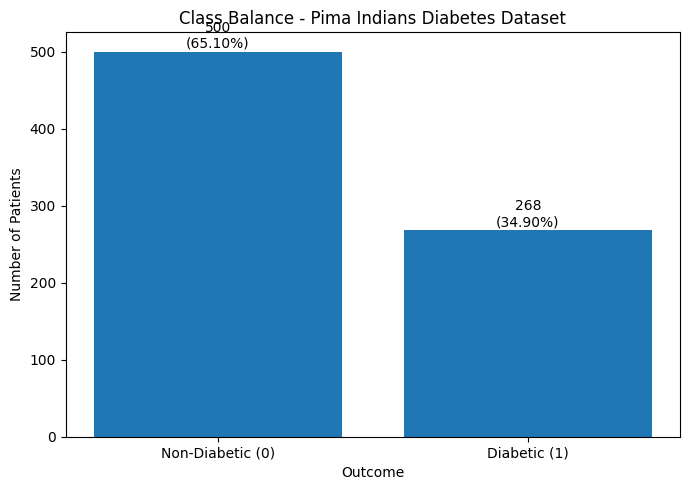

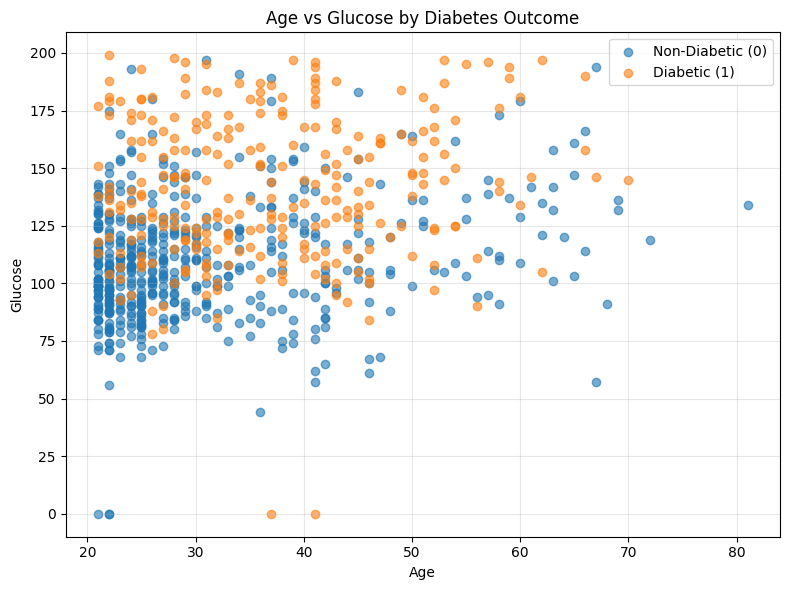


INTERPRETATION

The scatter plot shows considerable overlap between
diabetic and non-diabetic patients.

Higher glucose levels are generally associated with
a higher probability of diabetes. However, Age and
Glucose alone cannot completely separate the two classes.

Therefore, a simple linear decision boundary is not
sufficient for accurate classification.

Diabetes depends on multiple features such as Glucose,
BMI, Blood Pressure, Insulin, Pregnancies, Age, and
Diabetes Pedigree Function.

A Decision Tree can model non-linear relationships,
while Bagging combines multiple Decision Trees to
reduce variance and improve generalization.



In [ ]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------

df = pd.read_csv('diabetes_data/diabetes.csv')

print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Records:")
print(df.head())


# ------------------------------------------------------------
# 2. Calculate Class Distribution
# ------------------------------------------------------------

class_counts = df['Outcome'].value_counts().sort_index()

class_percentages = (
    df['Outcome'].value_counts(normalize=True).sort_index() * 100
)

print("\n===================================")
print("CLASS DISTRIBUTION")
print("===================================")

print(f"Non-Diabetic (0): {class_counts.loc[0]} "
      f"({class_percentages.loc[0]:.2f}%)")

print(f"Diabetic (1): {class_counts.loc[1]} "
      f"({class_percentages.loc[1]:.2f}%)")


# ------------------------------------------------------------
# 3. Bar Chart - Class Balance
# ------------------------------------------------------------

labels = ['Non-Diabetic (0)', 'Diabetic (1)']

counts = [
    class_counts.loc[0],
    class_counts.loc[1]
]

percentages = [
    class_percentages.loc[0],
    class_percentages.loc[1]
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, counts)

plt.title('Class Balance - Pima Indians Diabetes Dataset')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')

# Display count and percentage
for bar, count, percentage in zip(
    bars, counts, percentages
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Scatter Plot - Age vs Glucose
# ------------------------------------------------------------

non_diabetic = df[df['Outcome'] == 0]
diabetic = df[df['Outcome'] == 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    non_diabetic['Age'],
    non_diabetic['Glucose'],
    label='Non-Diabetic (0)',
    alpha=0.6
)

plt.scatter(
    diabetic['Age'],
    diabetic['Glucose'],
    label='Diabetic (1)',
    alpha=0.6
)

plt.title('Age vs Glucose by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------

print("\n===================================")
print("INTERPRETATION")
print("===================================")

print("""
The scatter plot shows considerable overlap between
diabetic and non-diabetic patients.

Higher glucose levels are generally associated with
a higher probability of diabetes. However, Age and
Glucose alone cannot completely separate the two classes.

Therefore, a simple linear decision boundary is not
sufficient for accurate classification.

Diabetes depends on multiple features such as Glucose,
BMI, Blood Pressure, Insulin, Pregnancies, Age, and
Diabetes Pedigree Function.

A Decision Tree can model non-linear relationships,
while Bagging combines multiple Decision Trees to
reduce variance and improve generalization.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# ============================================================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Identify features where 0 is physically impossible
# ------------------------------------------------------------

invalid_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Features where 0 is considered invalid:")
print(invalid_zero_features)


# ------------------------------------------------------------
# 2. Count invalid zero values before replacement
# ------------------------------------------------------------

print("\nNumber of invalid (0) values before replacement:")
print(df[invalid_zero_features].eq(0).sum())


# ------------------------------------------------------------
# 3. Replace invalid 0 values with NaN
# ------------------------------------------------------------

df[invalid_zero_features] = df[invalid_zero_features].replace(
    0, np.nan
)

print("\nInvalid 0 values replaced with NaN.")


# ------------------------------------------------------------
# 4. Check missing values after replacement
# ------------------------------------------------------------

print("\nMissing values after replacing 0 with NaN:")
print(df[invalid_zero_features].isnull().sum())


# ------------------------------------------------------------
# 5. Impute missing values using the median
# ------------------------------------------------------------

for column in invalid_zero_features:
    df[column] = df[column].fillna(df[column].median())


# ------------------------------------------------------------
# 6. Verify that no missing values remain
# ------------------------------------------------------------

print("\nMissing values after median imputation:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 7. Display final dataset information
# ------------------------------------------------------------

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFirst Five Records After Preprocessing:")
print(df.head())

print("\nDescriptive Statistics After Preprocessing:")
print(df.describe())


Features where 0 is considered invalid:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Number of invalid (0) values before replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Invalid 0 values replaced with NaN.

Missing values after replacing 0 with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Final Dataset Shape:
(768, 9)

First Five Records After Preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# ============================================================
# TASK 4: STRATIFIED TRAIN-TEST SPLITTING
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Separate Features (X) and Target (y)
# ------------------------------------------------------------

# First 8 columns are features
X = df.iloc[:, :8]

# 9th column is the target variable
y = df.iloc[:, 8]

print("Feature Matrix (X) Shape:", X.shape)
print("Target Vector (y) Shape:", y.shape)


# ------------------------------------------------------------
# 2. Split into 80% Training and 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 3. Display the shapes
# ------------------------------------------------------------

print("\n===================================")
print("TRAIN-TEST SPLIT")
print("===================================")

print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):  ", X_test.shape)

print("Training Target (y_train):  ", y_train.shape)
print("Testing Target (y_test):    ", y_test.shape)


# ------------------------------------------------------------
# 4. Check class distribution
# ------------------------------------------------------------

print("\n===================================")
print("CLASS DISTRIBUTION")
print("===================================")

print("\nOriginal Dataset:")
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTraining Dataset:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Dataset:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Feature Matrix (X) Shape: (768, 8)
Target Vector (y) Shape: (768,)

TRAIN-TEST SPLIT
Training Features (X_train): (614, 8)
Testing Features (X_test):   (154, 8)
Training Target (y_train):   (614,)
Testing Target (y_test):     (154,)

CLASS DISTRIBUTION

Original Dataset:
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

Training Dataset:
Outcome
0    400
1    214
Name: count, dtype: int64
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Testing Dataset:
Outcome
0    100
1     54
Name: count, dtype: int64
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# ============================================================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING FUNCTION
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Define Bootstrap Sampling Function
# ------------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample using sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        sample_indices : Original indices selected
    """

    # Number of samples in the training dataset
    N = len(X)

    # Randomly select N indices WITH replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[sample_indices].copy()
    y_bootstrap = y.iloc[sample_indices].copy()

    return X_bootstrap, y_bootstrap, sample_indices


# ------------------------------------------------------------
# 2. Generate One Bootstrap Sample
# ------------------------------------------------------------

# Set random seed for reproducibility
np.random.seed(42)

X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Verify Bootstrap Sample Size
# ------------------------------------------------------------

print("===================================")
print("BOOTSTRAP SAMPLE")
print("===================================")

print("Original Training Set Size:", len(X_train))
print("Bootstrap Sample Size:     ", len(X_bootstrap))

print("\nX Bootstrap Shape:", X_bootstrap.shape)
print("y Bootstrap Shape:", y_bootstrap.shape)


# ------------------------------------------------------------
# 4. Display Selected Original Indices
# ------------------------------------------------------------

print("\nFirst 30 Selected Indices:")
print(sample_indices[:30])


# ------------------------------------------------------------
# 5. Check for Duplicated Indices
# ------------------------------------------------------------

unique_indices, counts = np.unique(
    sample_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\n===================================")
print("DUPLICATE INDICES")
print("===================================")

print("Number of unique samples selected:",
      len(unique_indices))

print("Number of duplicated original indices:",
      len(duplicated_indices))

print("\nSome duplicated indices:")
print(duplicated_indices[:20])


# ------------------------------------------------------------
# 6. Find Out-of-Bag (OOB) Samples
# ------------------------------------------------------------

# All original training indices
original_indices = np.arange(len(X_train))

# Indices that were NOT selected
oob_indices = np.setdiff1d(
    original_indices,
    unique_indices
)

print("\n===================================")
print("OUT-OF-BAG (OOB) SAMPLES")
print("===================================")

print("Number of OOB samples:", len(oob_indices))

print("\nSome OOB indices:")
print(oob_indices[:20])


# ------------------------------------------------------------
# 7. Verify Bootstrap Property
# ------------------------------------------------------------

print("\n===================================")
print("VERIFICATION")
print("===================================")

if len(duplicated_indices) > 0:
    print("✓ Duplicate rows are present in the bootstrap sample.")
else:
    print("✗ No duplicate rows found.")

if len(oob_indices) > 0:
    print("✓ Some original rows were omitted (OOB samples).")
else:
    print("✗ No OOB samples found.")

if len(X_bootstrap) == len(X_train):
    print("✓ Bootstrap sample has the same size as training data.")
else:
    print("✗ Bootstrap sample size is incorrect.")

BOOTSTRAP SAMPLE
Original Training Set Size: 614
Bootstrap Sample Size:      614

X Bootstrap Shape: (614, 8)
y Bootstrap Shape: (614,)

First 30 Selected Indices:
[102 435 270 106  71  20 121 466 214 330 458  87 372  99 130 308 343 491
 413 385 191 276 160 459 313  21 252 560 474  58]

DUPLICATE INDICES
Number of unique samples selected: 377
Number of duplicated original indices: 164

Some duplicated indices:
[ 1  4  8 11 14 20 21 27 32 34 35 36 38 40 46 52 53 57 62 64]

OUT-OF-BAG (OOB) SAMPLES
Number of OOB samples: 237

Some OOB indices:
[ 2  3  5  6 10 12 23 25 29 30 31 33 39 43 44 49 51 54 55 56]

VERIFICATION
✓ Duplicate rows are present in the bootstrap sample.
✓ Some original rows were omitted (OOB samples).
✓ Bootstrap sample has the same size as training data.


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# ============================================================
# TASK 6: GROWING THE ENSEMBLE OF BASE CLASSIFIERS
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------------------------
# 1. Initialize Ensemble
# ------------------------------------------------------------

# Number of bootstrap iterations / decision trees
B = 50

# Empty list to store trained decision trees
ensemble = []

# Optional: store bootstrap indices for later OOB analysis
bootstrap_indices_list = []


# ------------------------------------------------------------
# 2. Train B Decision Trees
# ------------------------------------------------------------

# Random number generator
rng = np.random.default_rng(42)

for b in range(B):

    # Generate bootstrap sample
    N = len(X_train)

    sample_indices = rng.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap training data
    X_bootstrap = X_train.iloc[sample_indices]
    y_bootstrap = y_train.iloc[sample_indices]

    # Create a fully grown Decision Tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the tree
    tree.fit(X_bootstrap, y_bootstrap)

    # Store the trained model
    ensemble.append(tree)

    # Store indices for possible OOB analysis
    bootstrap_indices_list.append(sample_indices)


# ------------------------------------------------------------
# 3. Verify the Ensemble
# ------------------------------------------------------------

print("===================================")
print("ENSEMBLE TRAINING COMPLETE")
print("===================================")

print("Number of Decision Trees:", len(ensemble))
print("Expected Number of Trees:", B)

print("\nTree Details:")
print("Maximum Depth: None (Fully Grown)")

if len(ensemble) == B:
    print("\n✓ Successfully trained 50 Decision Trees.")
else:
    print("\n✗ Number of trees is incorrect.")

ENSEMBLE TRAINING COMPLETE
Number of Decision Trees: 50
Expected Number of Trees: 50

Tree Details:
Maximum Depth: None (Fully Grown)

✓ Successfully trained 50 Decision Trees.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# ============================================================
# TASK 7: CUSTOM BAGGING PREDICTION USING MAJORITY VOTING
# ============================================================

import numpy as np


# ------------------------------------------------------------
# 1. Define Custom Bagging Prediction Function
# ------------------------------------------------------------

def custom_bagging_predict(ensemble, X_test):
    """
    Generate predictions using majority voting
    from all Decision Trees in the ensemble.

    Parameters:
        ensemble : list
            List of trained Decision Tree classifiers.

        X_test : pandas DataFrame
            Test feature matrix.

    Returns:
        final_predictions : numpy array
            Majority-voted predictions.
    """

    # Store predictions from every tree
    all_predictions = []

    # Get prediction from each Decision Tree
    for tree in ensemble:
        predictions = tree.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    # Shape: (number_of_trees, number_of_test_samples)
    all_predictions = np.array(all_predictions)

    # --------------------------------------------------------
    # Majority Voting
    # --------------------------------------------------------

    final_predictions = []

    # Loop through every test sample
    for i in range(X_test.shape[0]):

        # Get votes from all trees for this sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_class_0 = np.sum(votes == 0)
        count_class_1 = np.sum(votes == 1)

        # Select the class with the majority
        if count_class_1 > count_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Convert to NumPy array
    return np.array(final_predictions)


# ------------------------------------------------------------
# 2. Generate Bagging Predictions
# ------------------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------------------
# 3. Display Results
# ------------------------------------------------------------

print("===================================")
print("CUSTOM BAGGING PREDICTIONS")
print("===================================")

print("Number of test samples:", len(X_test))
print("Number of trees:", len(ensemble))

print("\nFirst 20 predictions:")
print(y_pred_bagging[:20])

print("\nUnique predicted classes:")
print(np.unique(y_pred_bagging))


# ------------------------------------------------------------
# 4. Verify Predictions
# ------------------------------------------------------------

if np.all(np.isin(y_pred_bagging, [0, 1])):
    print("\n✓ All predictions are either 0 or 1.")
else:
    print("\n✗ Invalid prediction values found.")

if len(y_pred_bagging) == len(X_test):
    print("✓ Number of predictions matches test samples.")
else:
    print("✗ Number of predictions does not match test samples.")

CUSTOM BAGGING PREDICTIONS
Number of test samples: 154
Number of trees: 50

First 20 predictions:
[1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]

Unique predicted classes:
[0 1]

✓ All predictions are either 0 or 1.
✓ Number of predictions matches test samples.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

CONFUSION MATRIX - SINGLE DECISION TREE
[[79 21]
 [28 26]]

CONFUSION MATRIX - BAGGING
[[85 15]
 [21 33]]

PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy  : 0.6818
Precision : 0.5532
Recall    : 0.4815
F1-Score  : 0.5149

Bagging Ensemble:
Accuracy  : 0.7662
Precision : 0.6875
Recall    : 0.6111
F1-Score  : 0.6471

COMPARISON TABLE
               Model  Accuracy  Precision  Recall  F1-Score
Single Decision Tree    0.6818     0.5532  0.4815    0.5149
    Bagging Ensemble    0.7662     0.6875  0.6111    0.6471


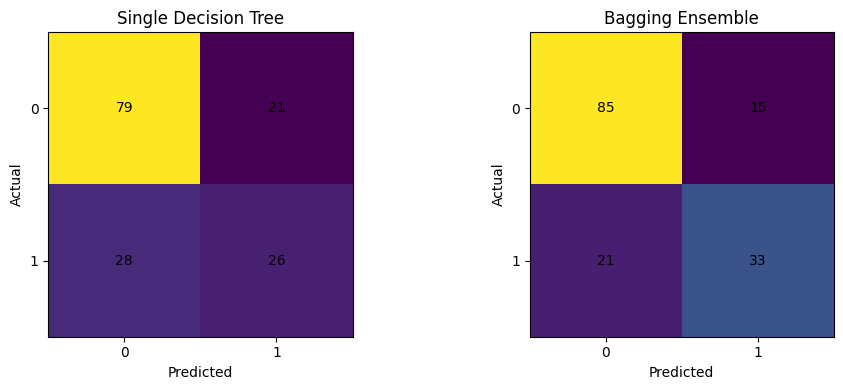


BAGGING IMPROVEMENT
Accuracy Change  : +0.0844
Precision Change : +0.1343
Recall Change    : +0.1296
F1-Score Change  : +0.1322


In [ ]:
# ============================================================
# TASK 8: SINGLE DECISION TREE vs BAGGING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# 1. Train a Single Fully-Grown Decision Tree
# ------------------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on ORIGINAL training data
single_tree.fit(X_train, y_train)


# ------------------------------------------------------------
# 2. Generate Predictions
# ------------------------------------------------------------

# Prediction from single Decision Tree
y_pred_single = single_tree.predict(X_test)

# Prediction from our custom Bagging ensemble
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------------------
# 3. Calculate Confusion Matrices
# ------------------------------------------------------------

cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)


# ------------------------------------------------------------
# 4. Display Confusion Matrices
# ------------------------------------------------------------

print("==============================================")
print("CONFUSION MATRIX - SINGLE DECISION TREE")
print("==============================================")

print(cm_single)


print("\n==============================================")
print("CONFUSION MATRIX - BAGGING")
print("==============================================")

print(cm_bagging)


# ------------------------------------------------------------
# 5. Calculate Performance Metrics
# ------------------------------------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(
    y_test,
    y_pred_single
)

precision_single = precision_score(
    y_test,
    y_pred_single,
    zero_division=0
)

recall_single = recall_score(
    y_test,
    y_pred_single,
    zero_division=0
)

f1_single = f1_score(
    y_test,
    y_pred_single,
    zero_division=0
)


# Bagging
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

recall_bagging = recall_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

f1_bagging = f1_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)


# ------------------------------------------------------------
# 6. Print Performance Results
# ------------------------------------------------------------

print("\n==============================================")
print("PERFORMANCE COMPARISON")
print("==============================================")

print("\nSingle Decision Tree:")
print(f"Accuracy  : {accuracy_single:.4f}")
print(f"Precision : {precision_single:.4f}")
print(f"Recall    : {recall_single:.4f}")
print(f"F1-Score  : {f1_single:.4f}")


print("\nBagging Ensemble:")
print(f"Accuracy  : {accuracy_bagging:.4f}")
print(f"Precision : {precision_bagging:.4f}")
print(f"Recall    : {recall_bagging:.4f}")
print(f"F1-Score  : {f1_bagging:.4f}")


# ------------------------------------------------------------
# 7. Create Comparison Table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Model': [
        'Single Decision Tree',
        'Bagging Ensemble'
    ],
    'Accuracy': [
        accuracy_single,
        accuracy_bagging
    ],
    'Precision': [
        precision_single,
        precision_bagging
    ],
    'Recall': [
        recall_single,
        recall_bagging
    ],
    'F1-Score': [
        f1_single,
        f1_bagging
    ]
})

print("\n==============================================")
print("COMPARISON TABLE")
print("==============================================")

print(comparison.round(4).to_string(index=False))


# ------------------------------------------------------------
# 8. Visualize Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Single Decision Tree
axes[0].imshow(cm_single)

axes[0].set_title('Single Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

for i in range(2):
    for j in range(2):
        axes[0].text(
            j, i,
            cm_single[i, j],
            ha='center',
            va='center'
        )

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])


# Bagging
axes[1].imshow(cm_bagging)

axes[1].set_title('Bagging Ensemble')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i,
            cm_bagging[i, j],
            ha='center',
            va='center'
        )

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Compare Improvement
# ------------------------------------------------------------

print("\n==============================================")
print("BAGGING IMPROVEMENT")
print("==============================================")

print(
    f"Accuracy Change  : "
    f"{accuracy_bagging - accuracy_single:+.4f}"
)

print(
    f"Precision Change : "
    f"{precision_bagging - precision_single:+.4f}"
)

print(
    f"Recall Change    : "
    f"{recall_bagging - recall_single:+.4f}"
)

print(
    f"F1-Score Change  : "
    f"{f1_bagging - f1_single:+.4f}"
)


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC RESULTS
Single Decision Tree AUC : 0.6357
Custom Bagging AUC       : 0.8001

AUC Improvement          : +0.1644


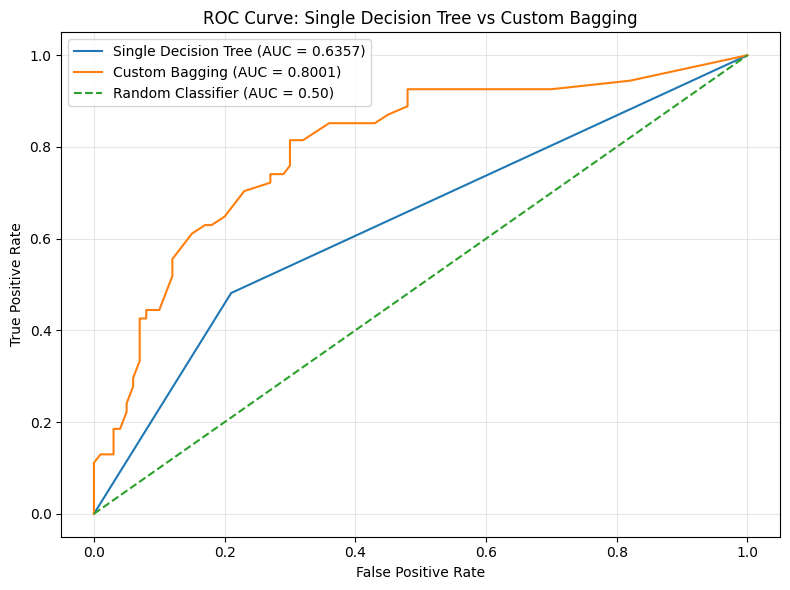


PROBABILITY VERIFICATION
Number of test samples: 154
Number of trees: 50

First 10 Single Tree probabilities:
[1. 0. 0. 1. 1. 0. 0. 1. 0. 1.]

First 10 Bagging probabilities:
[0.84 0.2  0.02 0.52 0.04 0.46 0.24 0.78 0.02 0.9 ]

Minimum Bagging probability: 0.0
Maximum Bagging probability: 1.0


In [ ]:
# ============================================================
# TASK 9: ROC-AUC ANALYSIS AND CURVE VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


# ------------------------------------------------------------
# 1. Single Decision Tree - Probability Predictions
# ------------------------------------------------------------

# Get probability of class 1 (Diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 2. Custom Bagging - Average Probabilities
# ------------------------------------------------------------

# Store probability predictions from every tree
all_probabilities = []

for tree in ensemble:

    # Get probability of class 1
    prob = tree.predict_proba(X_test)[:, 1]

    all_probabilities.append(prob)


# Convert to NumPy array
# Shape = (50 trees, 154 test samples)
all_probabilities = np.array(all_probabilities)


# Average probabilities across all 50 trees
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# ------------------------------------------------------------
# 3. Calculate ROC Curve
# ------------------------------------------------------------

# Single Decision Tree ROC
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

# Bagging ROC
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ------------------------------------------------------------
# 4. Calculate AUC
# ------------------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# ------------------------------------------------------------
# 5. Print AUC Results
# ------------------------------------------------------------

print("==============================================")
print("ROC-AUC RESULTS")
print("==============================================")

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Custom Bagging AUC       : {auc_bagging:.4f}")

print(
    f"\nAUC Improvement          : "
    f"{auc_bagging - auc_single:+.4f}"
)


# ------------------------------------------------------------
# 6. Plot ROC Curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Single Decision Tree
plt.plot(
    fpr_single,
    tpr_single,
    label=f'Single Decision Tree (AUC = {auc_single:.4f})'
)

# Bagging
plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f'Custom Bagging (AUC = {auc_bagging:.4f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)

plt.title('ROC Curve: Single Decision Tree vs Custom Bagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Verify Probability Predictions
# ------------------------------------------------------------

print("\n==============================================")
print("PROBABILITY VERIFICATION")
print("==============================================")

print("Number of test samples:", len(X_test))
print("Number of trees:", len(ensemble))

print("\nFirst 10 Single Tree probabilities:")
print(y_prob_single[:10])

print("\nFirst 10 Bagging probabilities:")
print(y_prob_bagging[:10])

print("\nMinimum Bagging probability:",
      y_prob_bagging.min())

print("Maximum Bagging probability:",
      y_prob_bagging.max())

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn Bagging Classifier trained successfully.

ACCURACY COMPARISON
Custom Bagging Accuracy     : 0.7662
Scikit-Learn Bagging Accuracy: 0.7338

CUSTOM BAGGING CONFUSION MATRIX
[[85 15]
 [21 33]]

SCIKIT-LEARN BAGGING CONFUSION MATRIX
[[85 15]
 [26 28]]

PERFORMANCE COMPARISON
   Metric  Custom Bagging  Scikit-Learn Bagging
 Accuracy          0.7662                0.7338
Precision          0.6875                0.6512
   Recall          0.6111                0.5185
 F1-Score          0.6471                0.5773


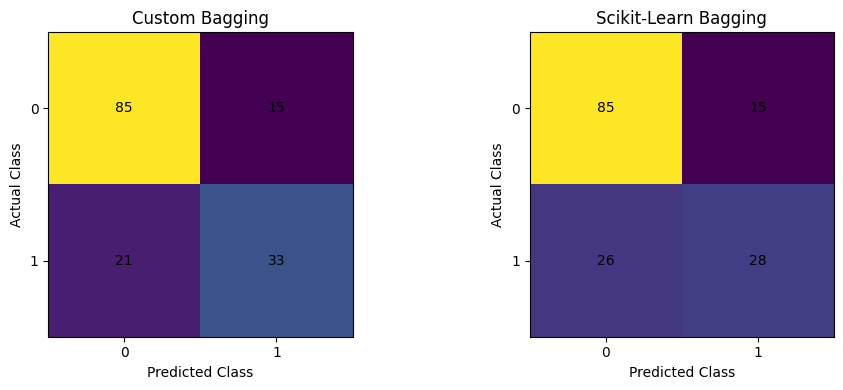


VALIDATION
Note: Confusion matrices differ.

Accuracy difference: 0.032467532467532534
✓ Custom and Scikit-Learn results are reasonably close.


In [ ]:
# ============================================================
# TASK 10: VALIDATION AGAINST SCIKIT-LEARN BAGGINGCLASSIFIER
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# 1. Create Scikit-Learn Bagging Classifier
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)


# ------------------------------------------------------------
# 2. Train Scikit-Learn Bagging Classifier
# ------------------------------------------------------------

sklearn_bagging.fit(
    X_train,
    y_train
)

print("Scikit-Learn Bagging Classifier trained successfully.")


# ------------------------------------------------------------
# 3. Predict Test Data
# ------------------------------------------------------------

y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# ------------------------------------------------------------
# 4. Custom Bagging Predictions
# ------------------------------------------------------------

# Predictions from your custom Bagging implementation
y_pred_custom = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------------------
# 5. Calculate Accuracy
# ------------------------------------------------------------

accuracy_custom = accuracy_score(
    y_test,
    y_pred_custom
)

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------------------------
# 6. Calculate Confusion Matrices
# ------------------------------------------------------------

cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------------------------
# 7. Display Results
# ------------------------------------------------------------

print("\n==============================================")
print("ACCURACY COMPARISON")
print("==============================================")

print(
    f"Custom Bagging Accuracy     : "
    f"{accuracy_custom:.4f}"
)

print(
    f"Scikit-Learn Bagging Accuracy: "
    f"{accuracy_sklearn:.4f}"
)


print("\n==============================================")
print("CUSTOM BAGGING CONFUSION MATRIX")
print("==============================================")

print(cm_custom)


print("\n==============================================")
print("SCIKIT-LEARN BAGGING CONFUSION MATRIX")
print("==============================================")

print(cm_sklearn)


# ------------------------------------------------------------
# 8. Calculate Other Performance Metrics
# ------------------------------------------------------------

precision_custom = precision_score(
    y_test,
    y_pred_custom,
    zero_division=0
)

recall_custom = recall_score(
    y_test,
    y_pred_custom,
    zero_division=0
)

f1_custom = f1_score(
    y_test,
    y_pred_custom,
    zero_division=0
)


precision_sklearn = precision_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

recall_sklearn = recall_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

f1_sklearn = f1_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)


# ------------------------------------------------------------
# 9. Create Comparison Table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Custom Bagging': [
        accuracy_custom,
        precision_custom,
        recall_custom,
        f1_custom
    ],
    'Scikit-Learn Bagging': [
        accuracy_sklearn,
        precision_sklearn,
        recall_sklearn,
        f1_sklearn
    ]
})

print("\n==============================================")
print("PERFORMANCE COMPARISON")
print("==============================================")

print(
    comparison.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 10. Visual Comparison of Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# Custom Bagging
axes[0].imshow(cm_custom)

axes[0].set_title(
    'Custom Bagging'
)

axes[0].set_xlabel(
    'Predicted Class'
)

axes[0].set_ylabel(
    'Actual Class'
)

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            cm_custom[i, j],
            ha='center',
            va='center'
        )


# Scikit-Learn Bagging
axes[1].imshow(cm_sklearn)

axes[1].set_title(
    'Scikit-Learn Bagging'
)

axes[1].set_xlabel(
    'Predicted Class'
)

axes[1].set_ylabel(
    'Actual Class'
)

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            cm_sklearn[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Validate the Results
# ------------------------------------------------------------

print("\n==============================================")
print("VALIDATION")
print("==============================================")

if np.array_equal(
    cm_custom,
    cm_sklearn
):
    print(
        "✓ Confusion matrices are identical."
    )
else:
    print(
        "Note: Confusion matrices differ."
    )

print(
    "\nAccuracy difference:",
    abs(accuracy_custom - accuracy_sklearn)
)

if abs(accuracy_custom - accuracy_sklearn) < 0.05:
    print(
        "✓ Custom and Scikit-Learn results "
        "are reasonably close."
    )
else:
    print(
        "The results differ noticeably. "
        "Check random seeds and bootstrap implementation."
    )

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?